In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sciris as sc
import hpvsim as hpv
from pathlib import Path

# Add project directories to path
project_dir = Path().absolute().parent.parent  # Go up from analysis/ to main project
sys.path.insert(0, str(project_dir))
sys.path.insert(0, str(project_dir / "hpv_scenarios"))

# Import project modules
import analyzers as an
import utils as ut
from core.seed_batch_manager import SeedBatchManager

print(f"HPVsim version: {hpv.__version__}")
print(f"Project directory: {project_dir}")

HPVsim 2.2.1 (2025-05-29) — © 2023-2025 by IDM
HPVsim version: 2.2.1
Project directory: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster


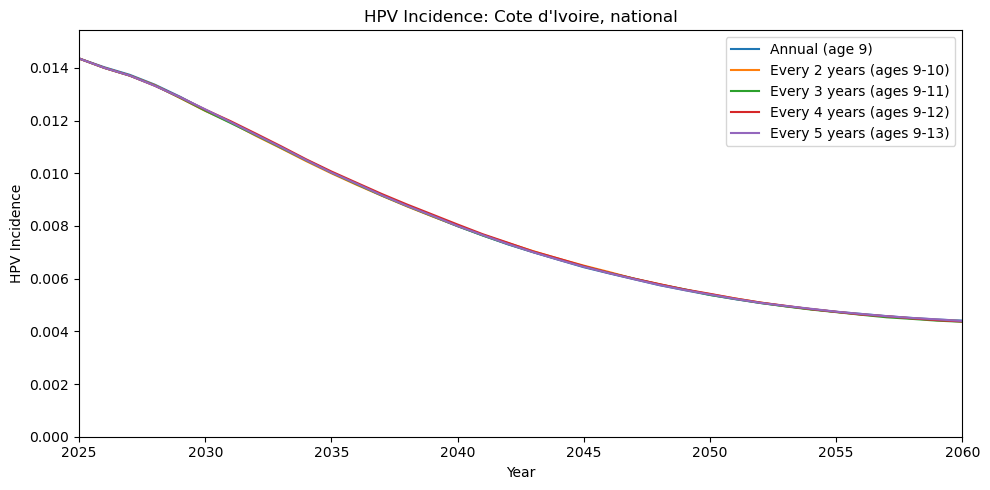

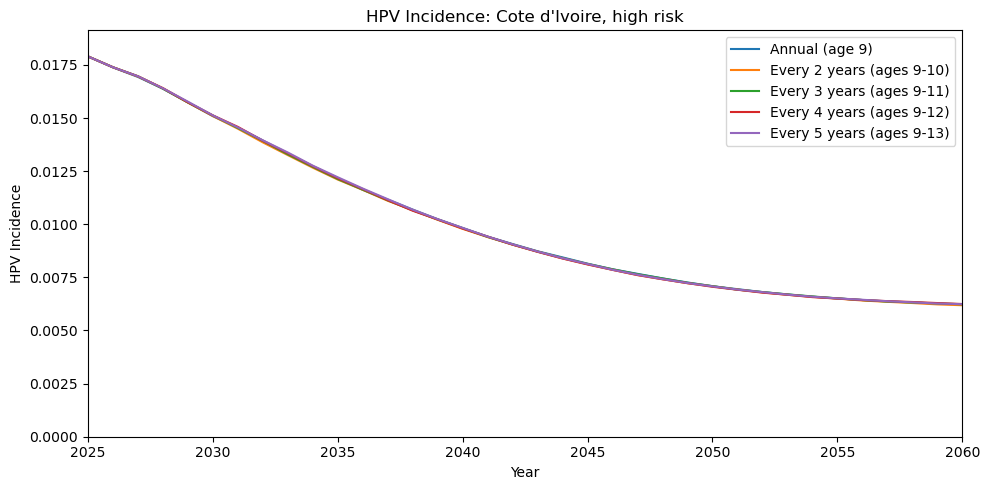

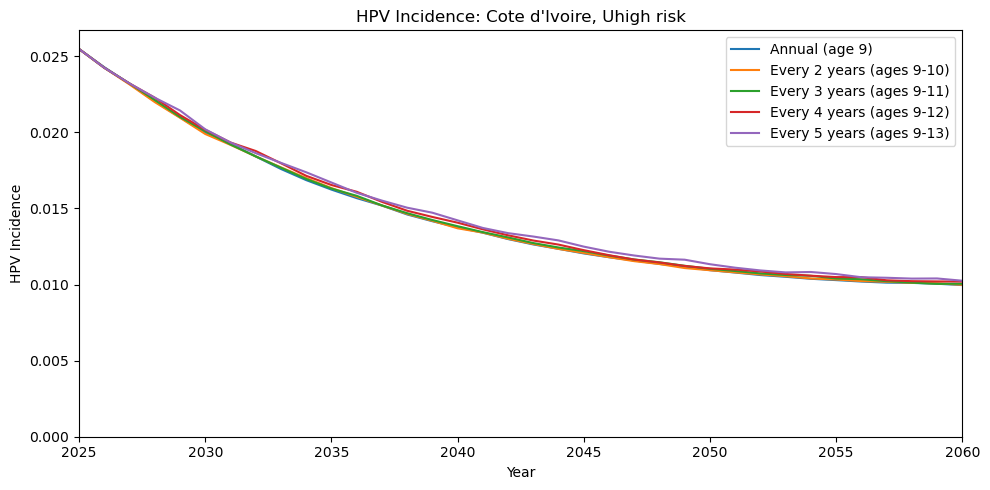

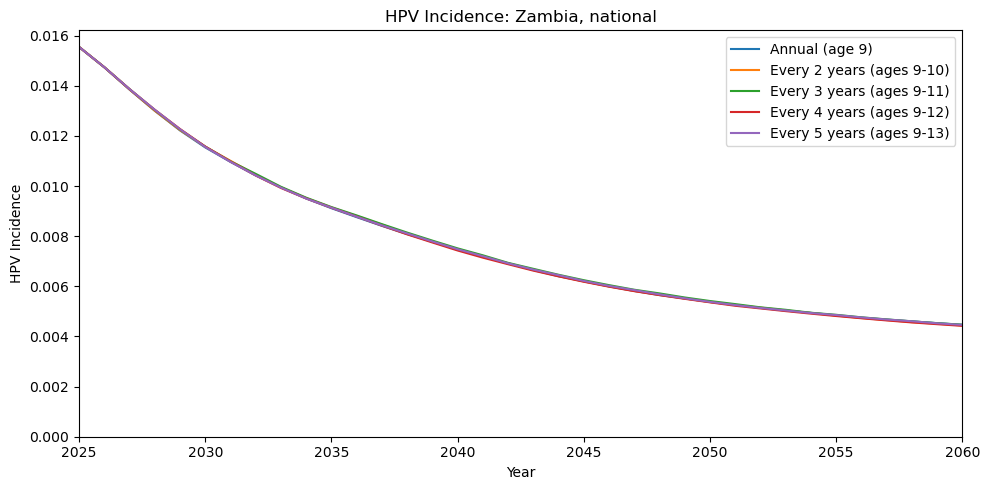

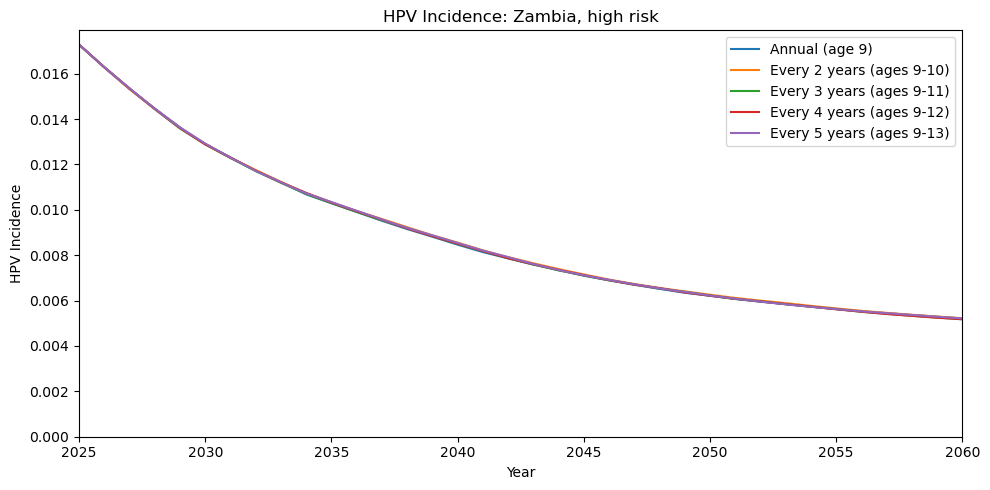

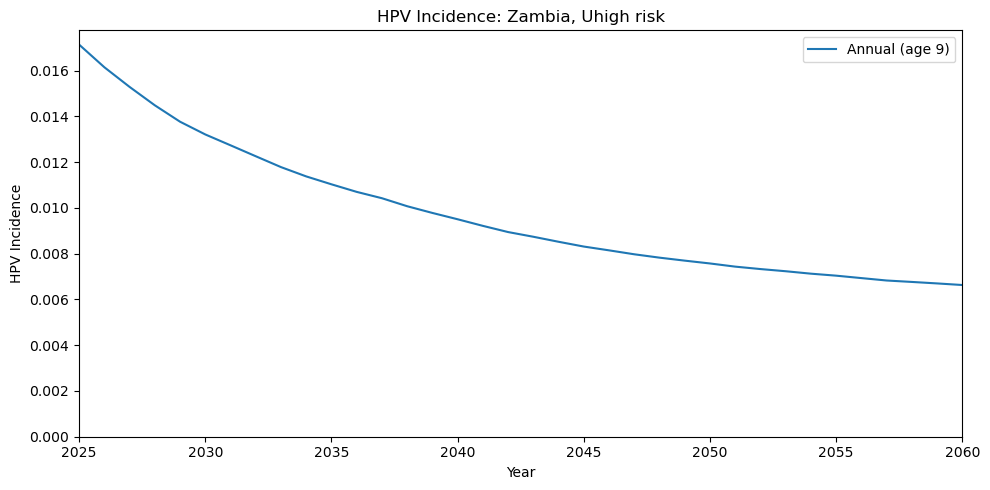

In [58]:
results_dir = project_dir / "hpv_scenarios" / "results" / "vaccination"
figure_dir = project_dir / "figures" 

# Example placeholders for loop values
countries = ['cote_d_ivoire', 'zambia']  # e.g., ['Kenya', 'India']
vx_scenarios = ['vx_annual_9-10', 'vx_biennial_9-11', 'vx_triennial_9-12', 
'vx_quadrennial_9-13', 'vx_quinquennial_9-14']#,'vx_sextennial_9-15', 'vx_septennial_9-16', 
#'vx_octennial_9-17', 'vx_nonennial_9-18', 'vx_decennial_9-19']  
risk_scenarios = ['NAT', 'HR', 'UHR']  # e.g., ['low', 'high']
calibration_sources = ['nov06']  # e.g., ['source1', 'source2']
scenario_labels = {
    'baseline': 'No vaccination',
    'vx_annual_9-10': 'Annual (age 9)',
    'vx_biennial_9-11': 'Every 2 years (ages 9-10)',
    'vx_triennial_9-12': 'Every 3 years (ages 9-11)',
    'vx_quadrennial_9-13': 'Every 4 years (ages 9-12)',
    'vx_quinquennial_9-14': 'Every 5 years (ages 9-13)'}
for country in countries:
    for risk_scenario in risk_scenarios:
        for calibration_source in calibration_sources:
            # Plot HPV incidence
            plt.figure(figsize=(10, 5))
            for vx_scenario in vx_scenarios:
                filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
                filepath = results_dir / filename
                if filepath.exists():
                    result = sc.loadobj(filepath)
                    t = result.results['t']+1960
                    #hpv_inc = (result.results['hpv_incidence_by_genotype'].values.T[:,0:3]).sum(axis=1)
                    hpv_inc = (result.results['hpv_incidence'].values)
                    plt.plot(t, hpv_inc, label=f"{scenario_labels[vx_scenario]}")
            # Set a descriptive title for the HPV incidence plot
            country_name = country.capitalize().replace('_d_ivoire', " d'Ivoire")
            risk_label = risk_scenario.replace('NAT', 'national').replace('HR', 'high risk')
            # Remove 'jul2' from calibration_source and replace 'nov06' with '3'
            calib_label = calibration_source.replace('jul2', '').replace('nov06', '3')
            plt.title(f"HPV Incidence: {country_name}, {risk_label}")
            plt.xlabel("Year")
            plt.ylabel("HPV Incidence")
            plt.legend()
            plt.xlim(2025, t[-1])
            # Set ylim: 0 to 1.1 * max(y) for x > 2010
            y_max = 0.01
            for line in plt.gca().get_lines():
                xdata = line.get_xdata()
                ydata = line.get_ydata()
                mask = xdata > 2025
                y_min=0
                if np.any(mask):
                    y_max = max(y_max, np.max(ydata[mask]))
                    y_min = min(y_min, np.min(ydata[mask]))
            plt.ylim(y_min, y_max * 1.1)
            plt.xticks(np.arange(2025, t[-1]+1, 5))
            plt.tight_layout()
            # Save the HPV incidence figure
            fig_filename = f"hpv_incidence_{country}_{risk_scenario}_{calibration_source}.png"
            plt.savefig(figure_dir / fig_filename)
            plt.show()
            plt.close()


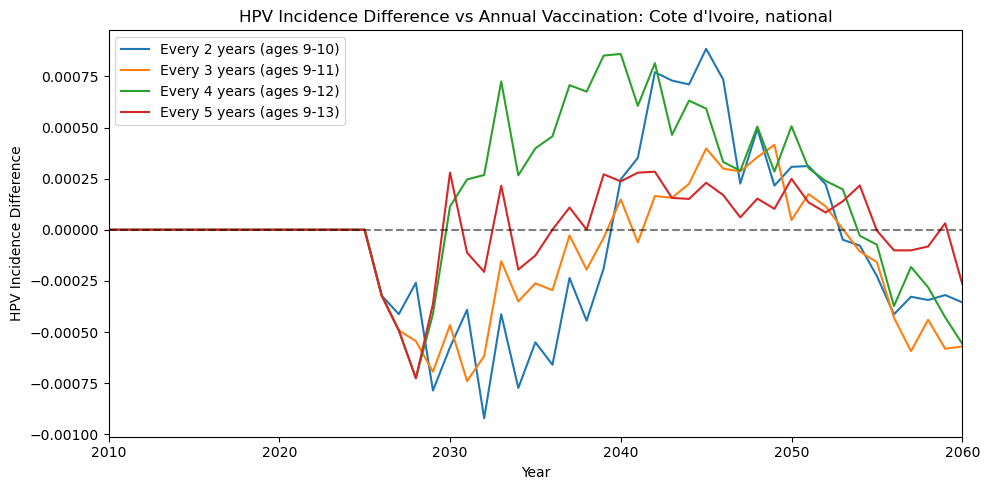

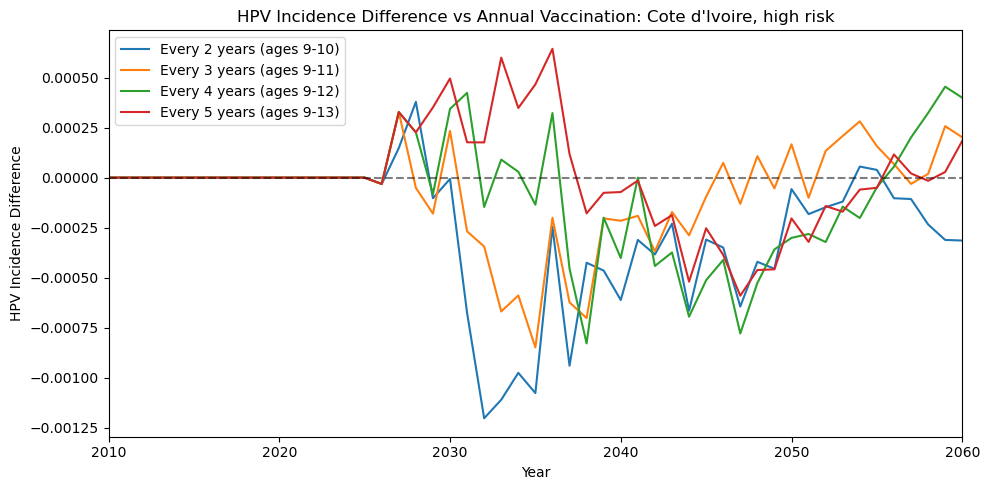

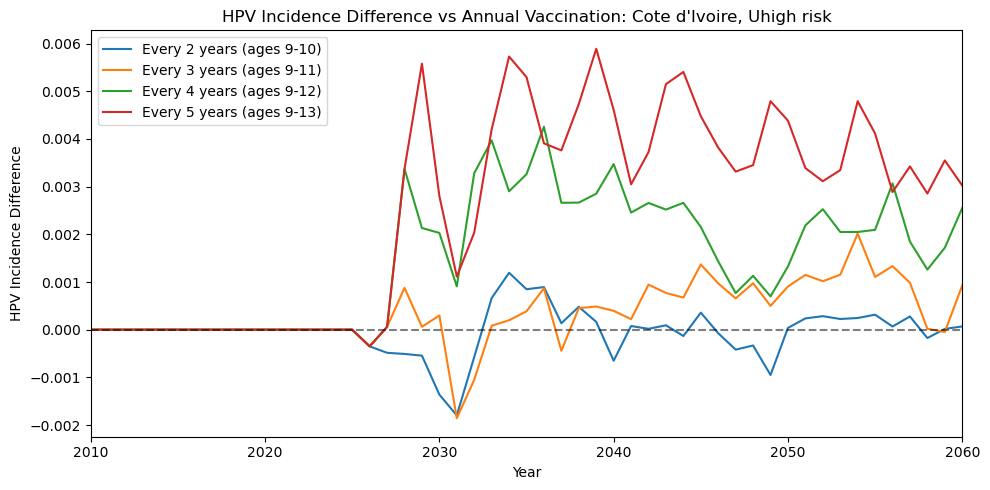

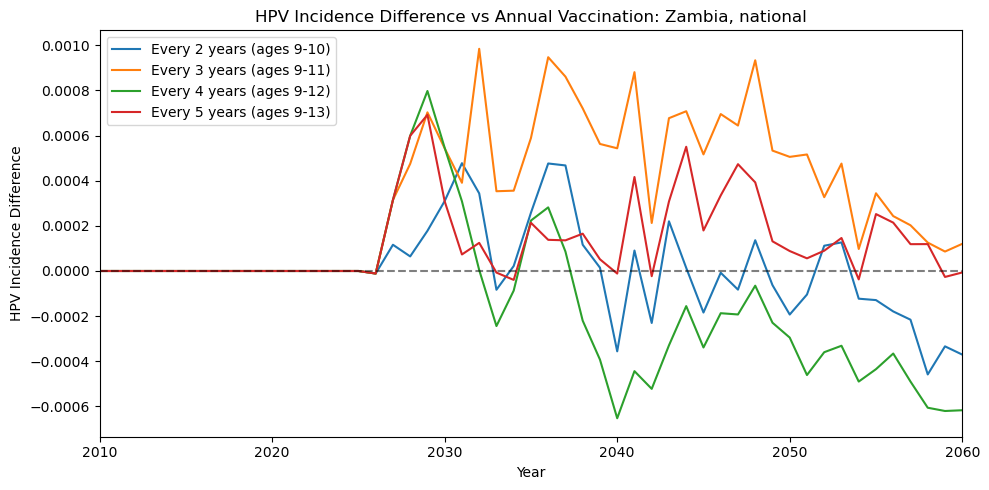

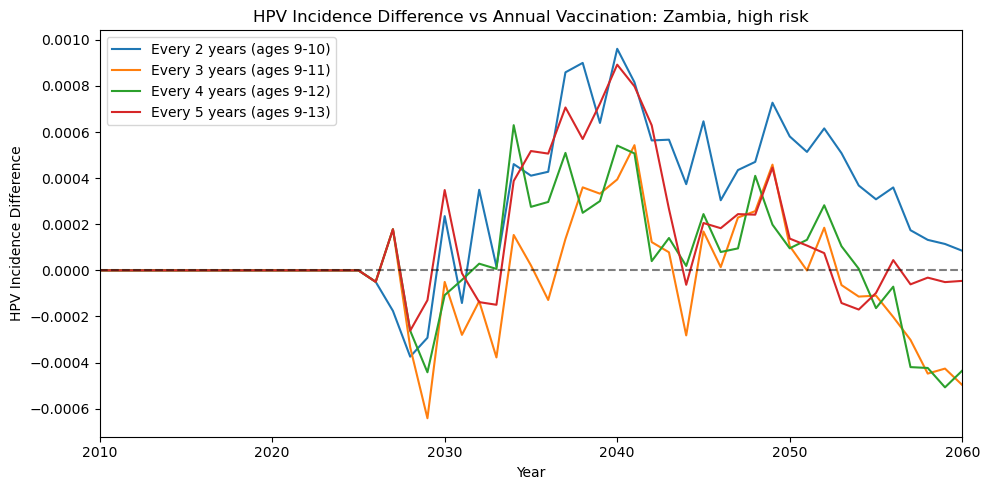

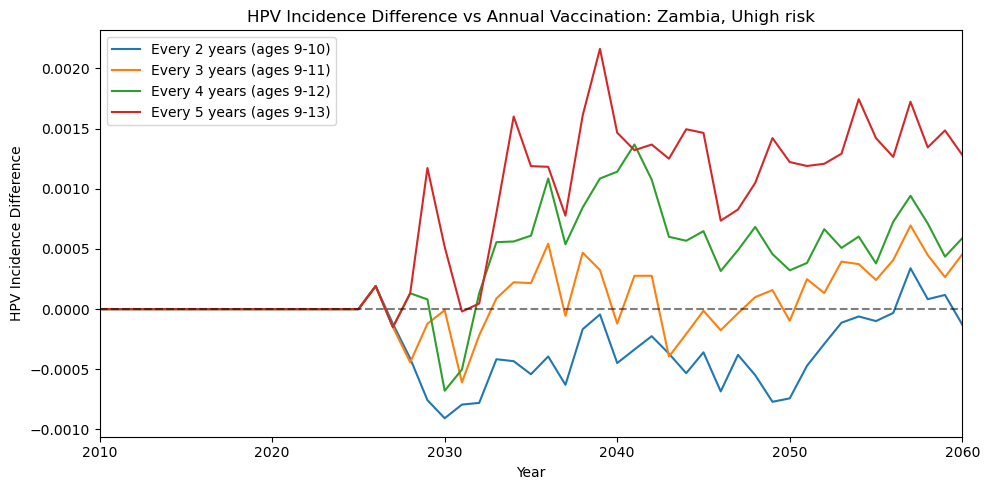

In [68]:
for country in countries:
           for risk_scenario in risk_scenarios:
               for calibration_source in calibration_sources:

                   # Load annual scenario as reference
                   annual_filename = f"{country}_vx_annual_9-10_{risk_scenario}_{calibration_source}.obj"
                   annual_filepath = results_dir / annual_filename

                   if not annual_filepath.exists():
                       print(f"Annual reference file not found: {annual_filename}")
                       continue

                   annual_result = sc.loadobj(annual_filepath)
                   annual_t = annual_result.results['t'] + 1960
                   annual_hpv_inc = (annual_result.results['hpv_incidence_by_genotype'].values.T[:,0:3]).sum(axis=1)

                   # Other vaccination scenarios (excluding baseline and annual)
                   other_vx_scenarios = ['vx_biennial_9-11','vx_triennial_9-12',
                                       'vx_quadrennial_9-13', 'vx_quinquennial_9-14']#,'vx_sextennial_9-15', 'vx_septennial_9-16',
                                       #'vx_octennial_9-17', 'vx_nonennial_9-18', 'vx_decennial_9-19']

                   # Plot HPV incidence differences
                   plt.figure(figsize=(10, 5))

                   for vx_scenario in other_vx_scenarios:
                       filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
                       filepath = results_dir / filename
                       if filepath.exists():
                           result = sc.loadobj(filepath)
                           t = result.results['t'] + 1960
                           hpv_inc = (result.results['hpv_incidence_by_genotype'].values.T[:,0:3]).sum(axis=1)

                           # Calculate difference (other scenario -annual scenario)
                           hpv_diff = hpv_inc- annual_hpv_inc

                           # Create cleaner labels
                           #scenario_label = vx_scenario.replace('vx_', '').replace('_9-', ' (ages 9-').replace('9-10', '10').replace('9-11','11').replace('9-12', '12').replace('9-13','13').replace('9-14', '14') + ')'
                           plt.plot(t, hpv_diff,
       label=scenario_labels[vx_scenario])

                   # Set plot properties
                   country_name =country.capitalize().replace('_d_ivoire', " d'Ivoire")
                   risk_label = risk_scenario.replace('NAT','national').replace('HR', 'high risk')
                   calib_label = calibration_source.replace('jul2','').replace('nov06', '3')

                   plt.title(f"HPV Incidence Difference vs Annual Vaccination: {country_name}, {risk_label}")
                   plt.xlabel("Year")
                   plt.ylabel("HPV Incidence Difference")
                   plt.legend()
                   plt.xlim(2010, t[-1])
                   plt.axhline(y=0, color='black', linestyle='--',alpha=0.5)  # Reference line at 0
                   plt.xticks(np.arange(2010, t[-1]+1, 10))
                   plt.tight_layout()

                   # Save the HPV incidence difference figure
                   fig_filename = f"hpv_incidence_diff_{country}_{risk_scenario}_{calibration_source}.png"
                   plt.savefig(figure_dir / fig_filename)
                   plt.show()
                   plt.close()

                   

NameError: name 'results' is not defined

In [42]:
# Extract total HPV infections and cancers from 2025-2060 for high risk scenarios

import pandas as pd
results_dir = project_dir / "hpv_scenarios" / "results" / "vaccination"

# Focus on high risk scenarios only
risk_scenario = 'HR'  # High risk only
countries = ['cote_d_ivoire', 'zambia']
vx_scenarios = ['baseline', 'vx_annual_9-10', 'vx_biennial_9-11', 'vx_triennial_9-12', 
               'vx_quadrennial_9-13', 'vx_quinquennial_9-14']
calibration_sources = ['nov06']

# Storage for results
results_data = []

for country in countries:
    for calibration_source in calibration_sources:
        country_data = {}
        
        for vx_scenario in vx_scenarios:
            filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
            filepath = results_dir / filename
            
            if filepath.exists():
                result = sc.loadobj(filepath)
                t = result.results['t'] + 1960
                
                # Find indices for years 2025-2060
                start_idx = np.where(t >= 2025)[0][0] if np.any(t >= 2025) else 0
                end_idx = np.where(t <= 2060)[0][-1] if np.any(t <= 2060) else len(t)-1
                
                # Calculate totals over the period
                hpv_infections = result.results['infections_by_genotype'][0:3, start_idx:end_idx+1]
                cancer_cases = result.results['cancers_by_genotype'][0:3, start_idx:end_idx+1]
                
                # Sum over the time period (these are annual rates, so sum gives total cases)
                total_hpv = np.sum(np.sum(hpv_infections))
                total_cancer = np.sum(np.sum(cancer_cases))
                
                country_data[vx_scenario] = {
                    'total_hpv_infections': total_hpv,
                    'total_cancers': total_cancer
                }
            else:
                print(f"File not found: {filename}")
                country_data[vx_scenario] = {
                    'total_hpv_infections': np.nan,
                    'total_cancers': np.nan
                }
        
        # Store results for this country/calibration combination
        for vx_scenario in vx_scenarios:
            if vx_scenario in country_data:
                results_data.append({
                    'country': country.replace('_d_ivoire', " d'Ivoire").replace('_', ' ').title(),
                    'calibration': calibration_source,
                    'scenario': vx_scenario,
                    'total_hpv_2025_2060': country_data[vx_scenario]['total_hpv_infections'],
                    'total_cancers_2025_2060': country_data[vx_scenario]['total_cancers']
                })

# Convert to DataFrame
results_df = pd.DataFrame(results_data)

# Display results
print("Total HPV Infections and Cancers (2025-2060) - High Risk Scenarios")
print("="*70)

for country in results_df['country'].unique():
    country_df = results_df[results_df['country'] == country]
    print(f"\n{country}:")
    print("-" * 40)
    
    for calib in country_df['calibration'].unique():
        calib_df = country_df[country_df['calibration'] == calib]
        print(f"\nCalibration: {calib}")
        
        # Format the data nicely
        display_df = calib_df.pivot_table(
            index='scenario',
            values=['total_hpv_2025_2060', 'total_cancers_2025_2060'],
            aggfunc='first'
        ).round(0)
        
        # Rename columns for clarity
        display_df.columns = ['Total Cancers', 'Total HPV Infections']
        display_df = display_df[['Total HPV Infections', 'Total Cancers']]  # Reorder columns
        
        print(display_df)

# Also create a summary comparing baseline vs vaccination scenarios
print("\n\nReduction vs Baseline:")
print("="*50)

for country in results_df['country'].unique():
    country_df = results_df[results_df['country'] == country]
    print(f"\n{country}:")
    
    for calib in country_df['calibration'].unique():
        calib_df = country_df[country_df['calibration'] == calib]
        baseline_row = calib_df[calib_df['scenario'] == 'baseline']
        
        if len(baseline_row) > 0:
            baseline_hpv = baseline_row['total_hpv_2025_2060'].iloc[0]
            baseline_cancer = baseline_row['total_cancers_2025_2060'].iloc[0]
            
            print(f"\nCalibration {calib}:")
            print("Scenario                  HPV Reduction    Cancer Reduction")
            print("-" * 55)
            
            for _, row in calib_df.iterrows():
                if row['scenario'] != 'baseline':
                    hpv_reduction = (baseline_hpv - row['total_hpv_2025_2060']) / baseline_hpv * 100
                    cancer_reduction = (baseline_cancer - row['total_cancers_2025_2060']) / baseline_cancer * 100
                    
                    scenario_name = row['scenario'].replace('vx_', '').replace('_9-', ' (9-').replace('10', '10)').replace('11', '11)').replace('12', '12)').replace('13', '13)').replace('14', '14)')
                    print(f"{scenario_name:<25} {hpv_reduction:>8.1f}%        {cancer_reduction:>8.1f}%")

# Save results to CSV
#results_df.to_csv(figure_dir / "hpv_cancer_totals_2025_2060_HR.csv", index=False)
#print(f"\n\nResults saved to: {figure_dir / 'hpv_cancer_totals_2025_2060_HR.csv'}")

Total HPV Infections and Cancers (2025-2060) - High Risk Scenarios

Cote D'Ivoire:
----------------------------------------

Calibration: nov06
                      Total HPV Infections  Total Cancers
scenario                                                 
baseline                       406277768.0      1808351.0
vx_annual_9-10                 193236724.0      1315169.0
vx_biennial_9-11               192766283.0      1313281.0
vx_quadrennial_9-13            193068647.0      1314037.0
vx_quinquennial_9-14           193196865.0      1315651.0
vx_triennial_9-12              193122030.0      1315779.0

Zambia:
----------------------------------------

Calibration: nov06
                      Total HPV Infections  Total Cancers
scenario                                                 
baseline                       267851079.0      1298427.0
vx_annual_9-10                 106132189.0       839062.0
vx_biennial_9-11               106508244.0       842286.0
vx_quadrennial_9-13            1

In [5]:
hpv_inc.values

array([0.01217264, 0.01004148, 0.00974832, 0.0093794 , 0.00911002,
       0.00878499, 0.00848911, 0.00828964, 0.00789543, 0.00763118,
       0.0074883 , 0.0071701 , 0.0069631 , 0.00672403, 0.00650647,
       0.00634751, 0.00616365, 0.00611782, 0.00605582, 0.00601178,
       0.00598487, 0.00594333, 0.00594038, 0.00603351, 0.00625003,
       0.00640076, 0.00660061, 0.00684589, 0.00701341, 0.00727746,
       0.00744412, 0.0076295 , 0.00782094, 0.00802271, 0.00826774,
       0.00844091, 0.00855887, 0.00873897, 0.00886055, 0.0089867 ,
       0.00921956, 0.00928295, 0.00934593, 0.00933815, 0.00928119,
       0.00924089, 0.00918362, 0.00912141, 0.00908922, 0.00907426,
       0.00902225, 0.0090175 , 0.0089124 , 0.0087804 , 0.0086914 ,
       0.00846062, 0.00841392, 0.00828274, 0.00815006, 0.00799273,
       0.0079168 , 0.00776137, 0.00758922, 0.00741759, 0.00721333,
       0.00700647, 0.00678752, 0.00653778, 0.00627774, 0.00604578,
       0.00582984, 0.00567716, 0.00555707, 0.00539715, 0.00528

['infections',
 'cins',
 'cancers',
 'cancer_deaths',
 'reinfections',
 'reactivations',
 'n_susceptible',
 'n_infectious',
 'n_inactive',
 'n_normal',
 'n_cin',
 'n_cancerous',
 'n_infected',
 'n_abnormal',
 'n_latent',
 'n_precin',
 'n_screened',
 'n_cin_treated',
 'n_cancer_treated',
 'n_vaccinated',
 'n_tx_vaccinated',
 'hpv_incidence',
 'cin_incidence',
 'cancer_incidence',
 'births',
 'other_deaths',
 'migration',
 'asr_cancer_incidence',
 'asr_cancer_mortality',
 'new_vaccinated',
 'cum_vaccinated',
 'new_doses',
 'cum_doses',
 'new_txvx_doses',
 'new_tx_vaccinated',
 'cum_txvx_doses',
 'cum_tx_vaccinated',
 'new_screens',
 'new_screened',
 'new_cin_treatments',
 'new_cin_treated',
 'new_cancer_treatments',
 'new_cancer_treated',
 'cum_screens',
 'cum_screened',
 'cum_cin_treatments',
 'cum_cin_treated',
 'cum_cancer_treatments',
 'cum_cancer_treated',
 'cancer_mortality',
 'n_alive',
 'cdr',
 'cbr',
 'hpv_prevalence',
 'precin_prevalence',
 'cin_prevalence',
 'infections_by_gen

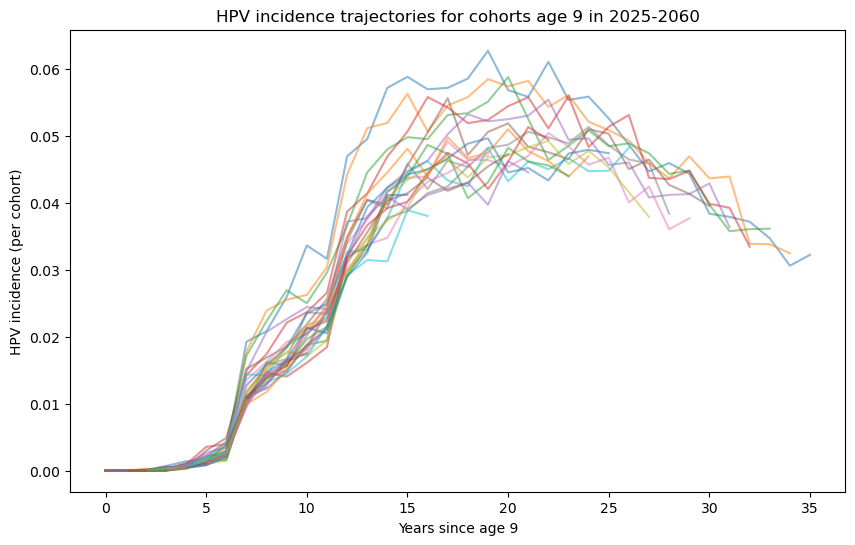

Bad pipe message: %s [b'\x95=\xf5\x00\xb8\xa4\x9c$\x1e1%\xea\xd79\r\t\xa7\xfc\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07\xc0\x08\xc0']
Bad pipe message: %s [b'\n\xc0\x0b\xc0\x0c\xc0\r\xc0']
Bad pipe message: %s [b'\x7f\x89M\x7fz?Q=!\x8e\x1f\xe4h\x03\xde\xc7\x8e#\x00\x01|\x00\x

In [ ]:
#plt.plot(result.results['hpv_incidence_by_age'].values.T)
country = 'cote_d_ivoire'
vx_scenario = 'vx_annual_9-10'
alt_scenario = 'vx_quinquennial_9-14'
risk_scenario = 'HR'
calibration_source = 'nov06'
filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)

age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
years = np.arange(1960, 2061)

incidence_by_age = result.results['hpv_incidence_by_age'].values
incidence_by_age.shape

# Extract cohort incidence trajectories for girls age 9 in 2025, 2026, ..., 2060
cohort_matrix = []

for start_year in range(2025, 2061):
    # Index in years array for this cohort's starting year
    year_idx = start_year - 1960
    # For each year after start_year, track the cohort as it ages
    cohort = []
    for offset in range(0, 2061 - start_year):
        age = 9 + offset
        # Find the age bin index for this age
        if age < 60:
            age_bin_idx = age - 8  # since 8-9 is index 1, 9-10 is index 2, etc.
        elif age == 60:
            age_bin_idx = 52
        elif age == 70:
            age_bin_idx = 53
        elif age == 80:
            age_bin_idx = 54
        elif age == 90:
            age_bin_idx = 55
        elif age == 100:
            age_bin_idx = 56
        else:
            # If age is not in the defined bins, skip
            continue
        year_pos = year_idx + offset
        if year_pos < incidence_by_age.shape[1]:
            cohort.append(incidence_by_age[age_bin_idx, year_pos])
    cohort_matrix.append(cohort)

# Convert to object array for ragged rows (since cohorts are different lengths)
cohort_matrix = np.array(cohort_matrix, dtype=object)

# Example plot: plot all cohort trajectories
plt.figure(figsize=(10, 6))
for cohort in cohort_matrix:
    plt.plot(cohort, alpha=0.5)
plt.xlabel('Years since age 9')
plt.ylabel('HPV incidence (per cohort)')
plt.title('HPV incidence trajectories for cohorts age 9 in 2025-2060')
plt.show()

In [69]:
country = 'cote_d_ivoire'
vx_scenario = 'baseline'
risk_scenario = 'HR'
calibration_source = 'jul22'
filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)
plt.plot(result.results['hpv_incidence_by_genotype'].values.T)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/cote_d_ivoire_baseline_HR_jul22.obj'

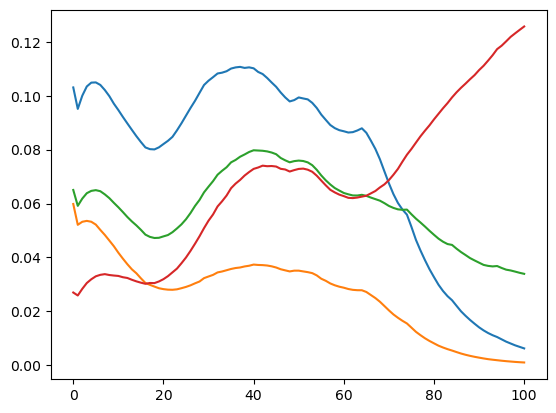

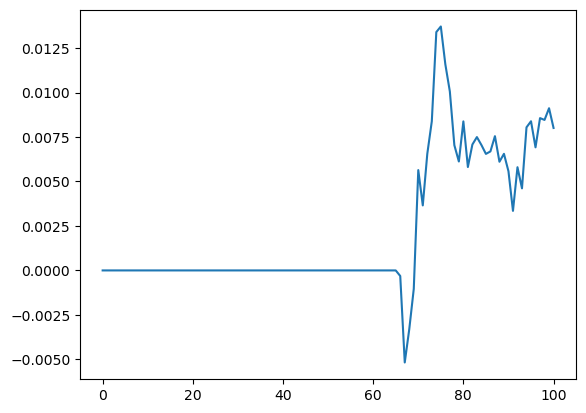

In [87]:
country = 'cote_d_ivoire'
vx_scenario = 'vx_annual_9-10'
alt_scenario = 'vx_decennial_9-19'
risk_scenario = 'HR'
calibration_source = 'nov06'
filename = f"{country}_{alt_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)
res = result.results['hpv_incidence_by_genotype'].values.T
filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)
plt.plot(((res-result.results['hpv_incidence_by_genotype'].values.T)).sum(axis=1))

In [77]:
results_dir = project_dir / "hpv_scenarios" / "results" / "vaccination"
figure_dir = project_dir / "figures" 

In [125]:
def plot_seed_incidence(country, risk_scenario, calibration_source, seed, results_dir):
    """
    Plot simulated HPV incidence for baseline and all vaccination scenarios for a specific seed.
    """
    vx_scenarios = ['baseline', 'vx_annual_9-10', 'vx_biennial_9-11', 'vx_triennial_9-12', 
                    'vx_quadrennial_9-13', 'vx_quinquennial_9-14']
    temp_dir = results_dir / "temp_sims"
    plt.figure(figsize=(10, 5))
    for vx_scenario in vx_scenarios:
        filename = f"{country}_{vx_scenario}_{risk_scenario}_seed{seed}_{calibration_source}.obj"
        filepath = temp_dir / filename
        if filepath.exists():
            result = sc.loadobj(filepath)
            t = result.results['t'] + 1960
            hpv_inc = result.results['infections']
            plt.plot(t, hpv_inc, label=vx_scenario)
        else:
            print(f"File not found: {filename}")
    country_name = country.capitalize().replace('_d_ivoire', " d'Ivoire")
    risk_label = risk_scenario.replace('NAT', 'national').replace('HR', 'high risk')
    plt.title(f"HPV Infections by Scenario\n{country_name}, {risk_label}, seed {seed}")
    plt.xlabel("Year")
    plt.ylabel("HPV Infections")
    plt.legend()
    plt.tight_layout()
    plt.xlim(2020, 2060)
    #plt.ylim(1e6, 1.7e6)
    plt.show()

# Example usage:

File not found: zambia_baseline_HR_seed7_jul22.obj


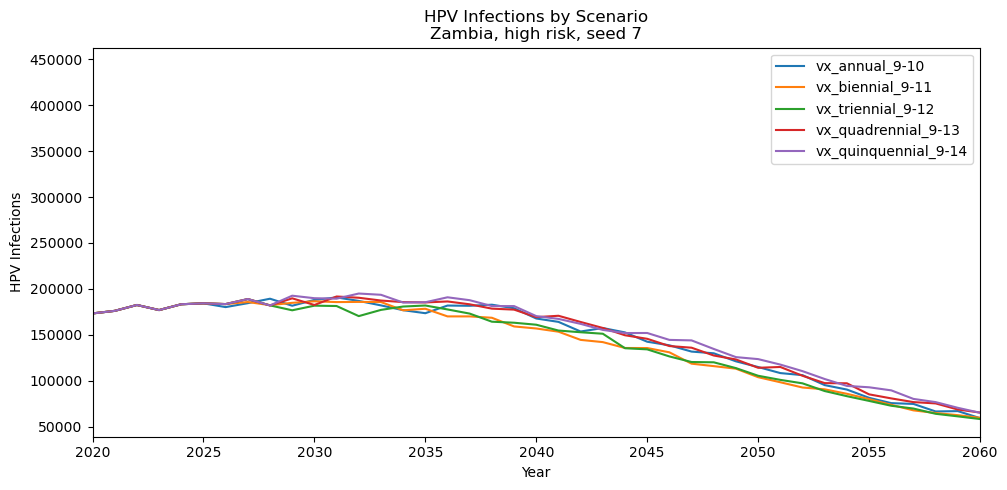

In [178]:
plot_seed_incidence('zambia', 'HR', 'jul22',7,results_dir)

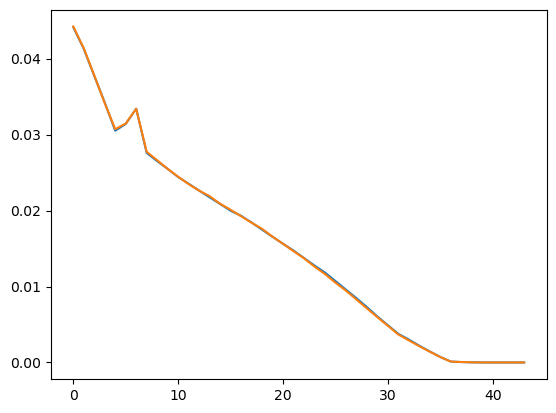

In [37]:
country = 'cote_d_ivoire'
vx_scenario = 'vx_annual_9-10'
alt_scenario = 'vx_quinquennial_9-14'
risk_scenario = 'NAT'
calibration_source = 'nov06'
filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result1 = sc.loadobj(filepath)
filename = f"{country}_{alt_scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result2 = sc.loadobj(filepath)
hpv_incidence_by_age1 = result1.results['hpv_incidence_by_age'].values
hpv_incidence_by_age2 = result2.results['hpv_incidence_by_age'].values
age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
years = np.arange(1960, 2061)
# Sum the upper triangle of the incidence matrix corresponding to cohorts born after 2016
# Each column is a year, each row is an age bin (starting at age 8)
# For each cohort born in year y (after 2016), their incidence is on the diagonal and below (as they age)
# So, sum the lower triangle starting from the column corresponding to 2017 (birth year)

# Find the column index for year 2017 (birth year > 2016)
start_col = np.where(years == 2017)[0][0]

# Only consider ages >= 0 (i.e., age_bin_idx >= 0), which is row index 8 (age 8) and up
# But since age_bin_edges starts at 0, and bins are [0-8), [8-9), [9-10), ..., [100+)
# hpv_incidence_by_age[0, :] is 0-8, [1, :] is 8-9, [2, :] is 9-10, etc.

# We'll assume age 0 is not modeled, so start from age 8 (row 1) for age 8 in 2017, age 9 in 2018, etc.
# For each cohort born in 2017+, sum the diagonal and below in the submatrix

n_years = hpv_incidence_by_age1.shape[1]
n_ages = hpv_incidence_by_age1.shape[0]
n_cohorts = n_years - start_col

cohort_sums1 = []
cohort_sums2 = []
for i in range(n_cohorts):
    # For cohort born in years[start_col + i], sum incidence as they age
    # They start at age_bin_idx = 1 (age 8-9), year_idx = start_col + i
    cohort_sum1 = 0.0
    cohort_sum2 = 0.0
    for j in range(n_ages):
        year_idx = start_col + i + j
        if year_idx >= n_years:
            break
        cohort_sum1 += (hpv_incidence_by_age1[j, year_idx] - cohort_sum1)/(j+1)
        cohort_sum2 += (hpv_incidence_by_age2[j, year_idx] - cohort_sum2)/(j+1)
    cohort_sums1.append(cohort_sum1)
    cohort_sums2.append(cohort_sum2)

cohort_sums1 = np.array(cohort_sums1)
cohort_sums2 = np.array(cohort_sums2)
# cohort_sums[i] is the total HPV incidence for the cohort born in years[start_col + i]
plt.plot(cohort_sums1)
plt.plot(cohort_sums2)


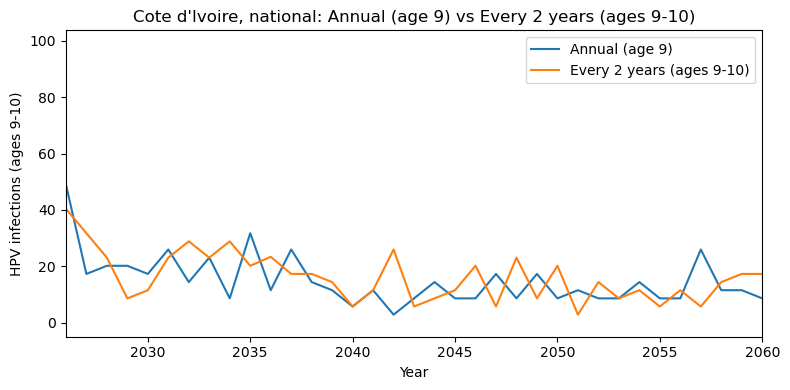

Mean annual absolute difference in infections : 1.3278068814958812
cote_d_ivoire, NAT, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 522.4631587982178
Alternative scenario sum: 568.9363996505737


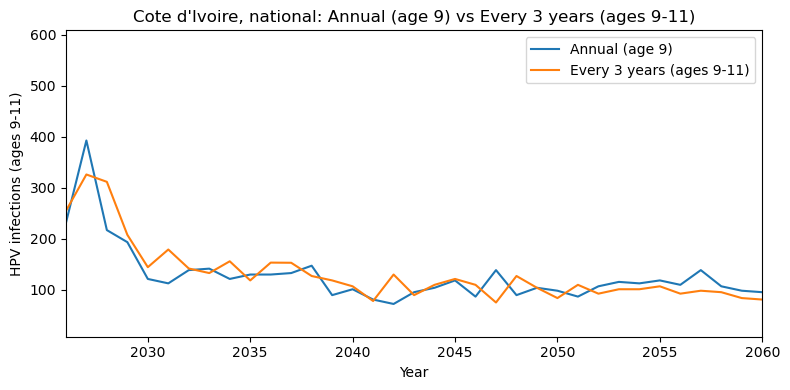

Mean annual absolute difference in infections : 4.13187122889927
cote_d_ivoire, NAT, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 4474.997961425781
Alternative scenario sum: 4619.613454437255


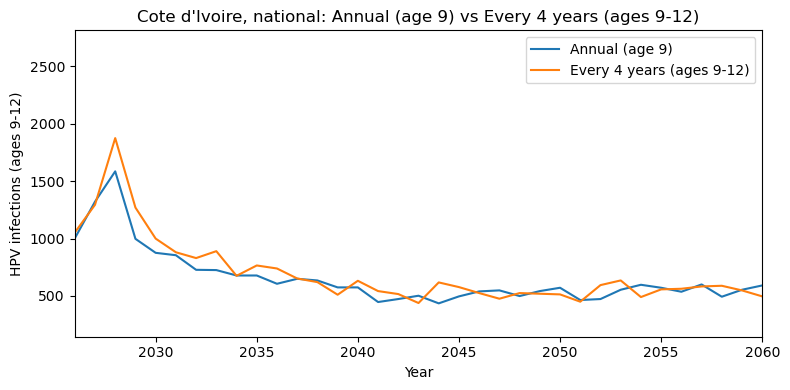

Mean annual absolute difference in infections : 41.89601769583564
cote_d_ivoire, NAT, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 22979.430509185793
Alternative scenario sum: 24445.79112854004


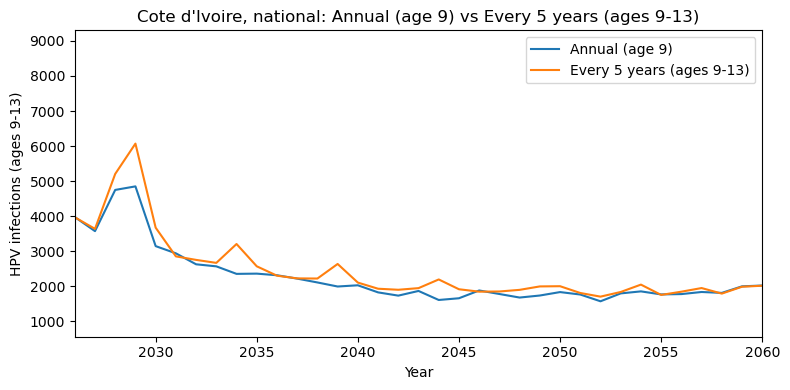

Mean annual absolute difference in infections : 191.73196874891
cote_d_ivoire, NAT, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 79478.18058547974
Alternative scenario sum: 86188.79949169159


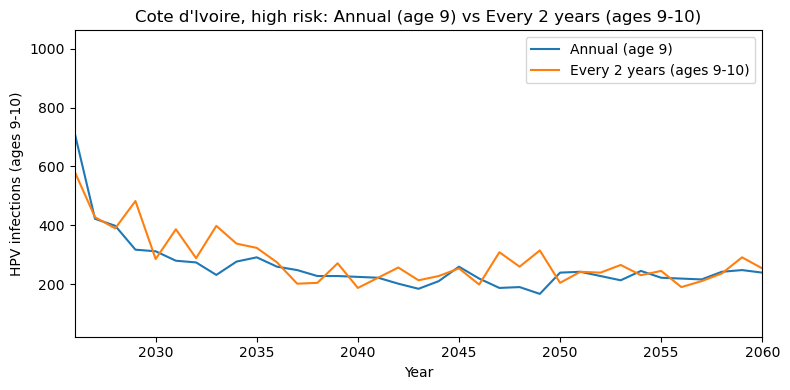

Mean annual absolute difference in infections : 23.001576227460568
cote_d_ivoire, HR, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 9108.466978645325
Alternative scenario sum: 9913.522146606445


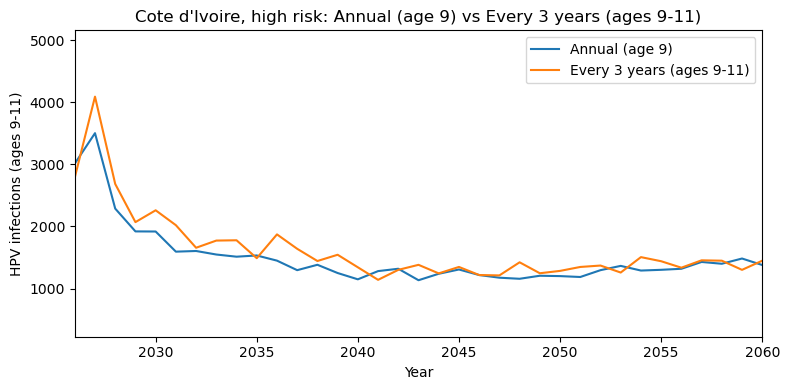

Mean annual absolute difference in infections : 129.08590075356582
cote_d_ivoire, HR, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 52665.722162818915
Alternative scenario sum: 57183.72868919372


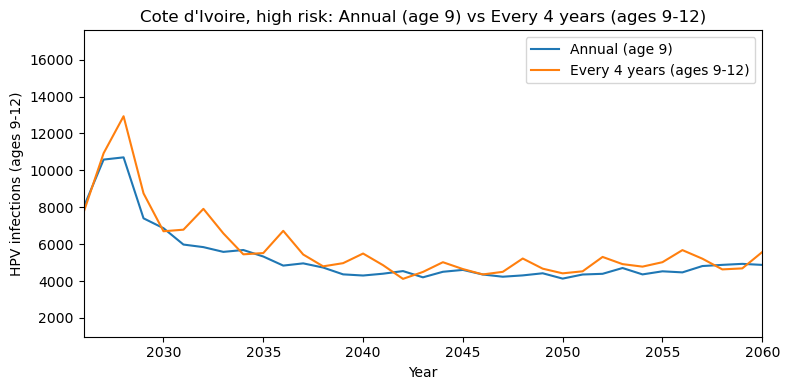

Mean annual absolute difference in infections : 519.8820971243724
cote_d_ivoire, HR, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 185115.93631076813
Alternative scenario sum: 203311.80971012116


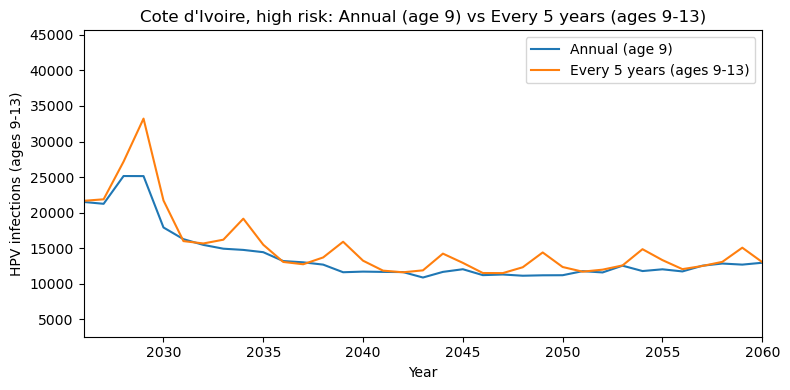

Mean annual absolute difference in infections : 1317.3644721419485
cote_d_ivoire, HR, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 485826.75296115875
Alternative scenario sum: 531934.509486127


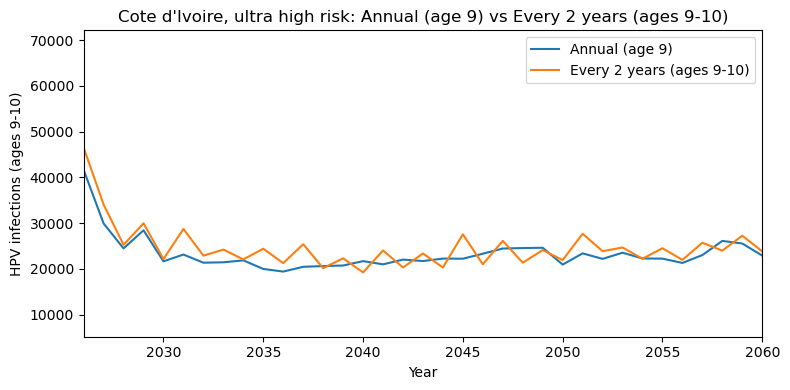

Mean annual absolute difference in infections : 1371.8705187988335
cote_d_ivoire, UHR, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 816125.2287475585
Alternative scenario sum: 864140.6969055177


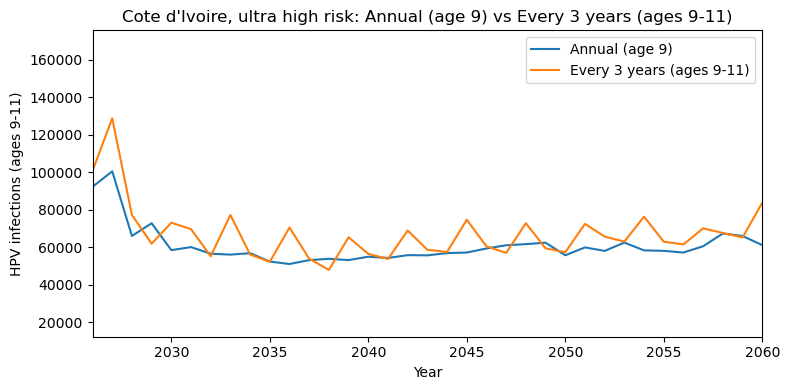

Mean annual absolute difference in infections : 6516.566526576451
cote_d_ivoire, UHR, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 2129833.3349975585
Alternative scenario sum: 2357913.1634277343


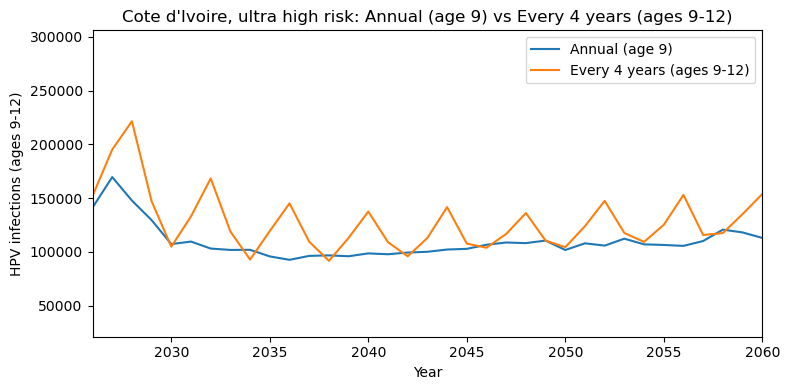

Mean annual absolute difference in infections : 18700.425609654016
cote_d_ivoire, UHR, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 3829010.967614746
Alternative scenario sum: 4483525.863952637


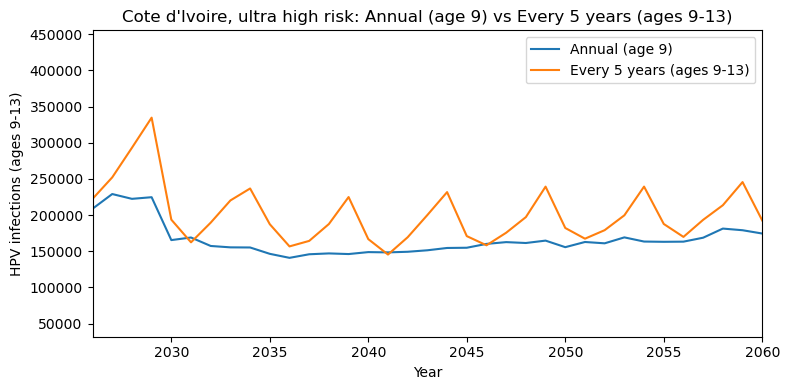

Mean annual absolute difference in infections : 35396.285547921274
cote_d_ivoire, UHR, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 5812434.346911622
Alternative scenario sum: 7051304.341088867


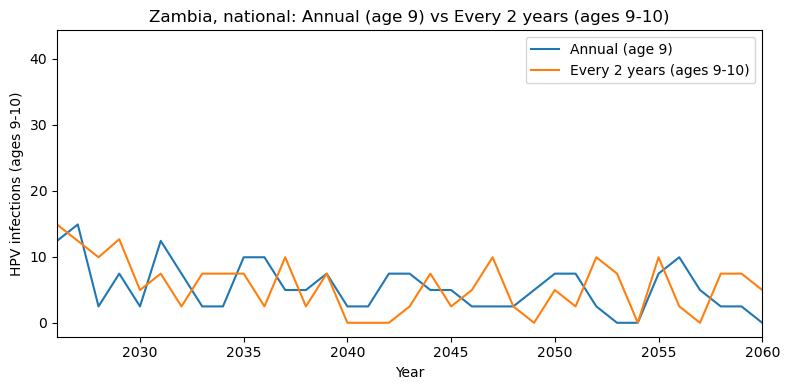

Mean annual absolute difference in infections : 0.21997670309884176
zambia, NAT, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 188.75421218872071
Alternative scenario sum: 196.45339679718018


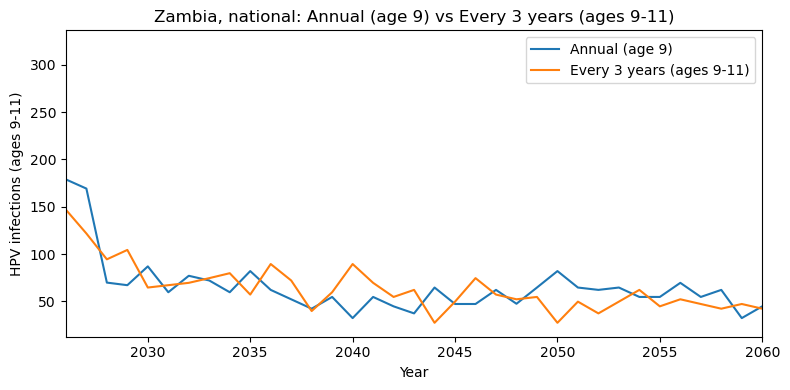

Mean annual absolute difference in infections : -1.3553404290335362
zambia, NAT, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 2280.697265052795
Alternative scenario sum: 2233.2603500366213


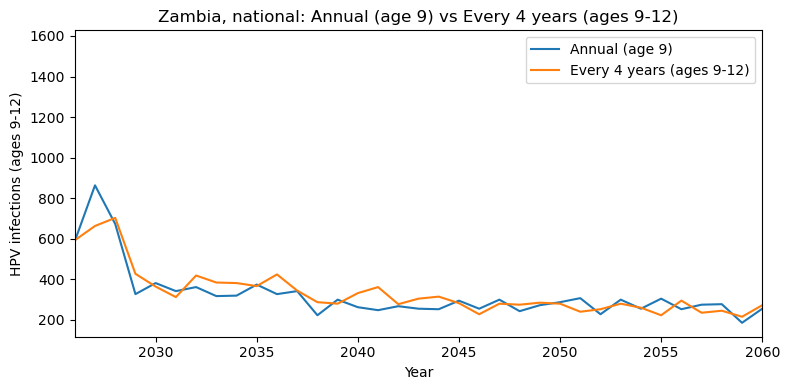

Mean annual absolute difference in infections : 10.622747917175209
zambia, NAT, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 11259.18843803406
Alternative scenario sum: 11630.984615135192


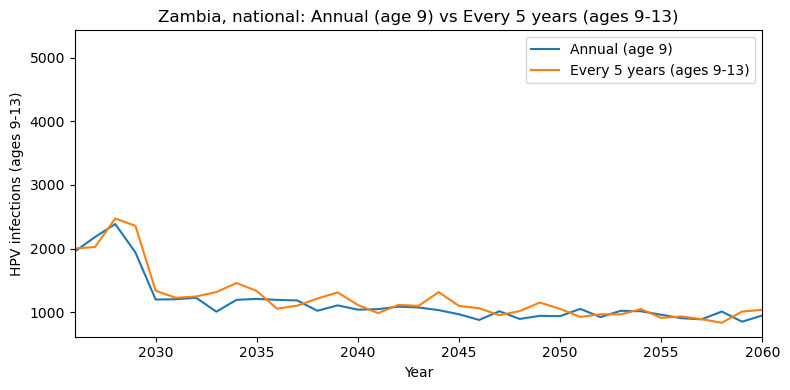

Mean annual absolute difference in infections : 69.83196026938239
zambia, NAT, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 40526.27388801575
Alternative scenario sum: 42970.39249744413


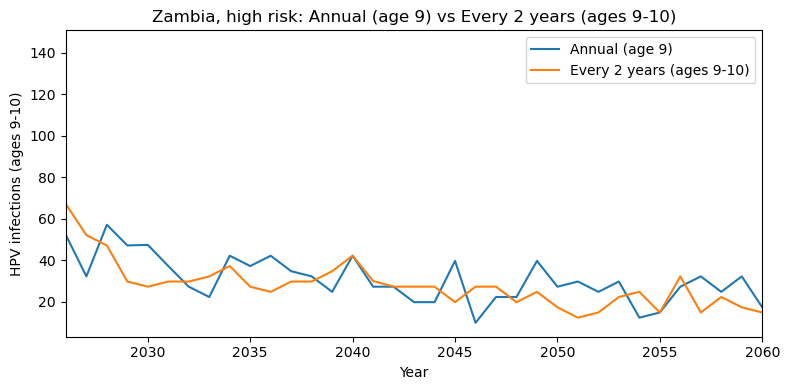

Mean annual absolute difference in infections : -2.838409135001049
zambia, HR, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 1080.617860031128
Alternative scenario sum: 981.2735403060913


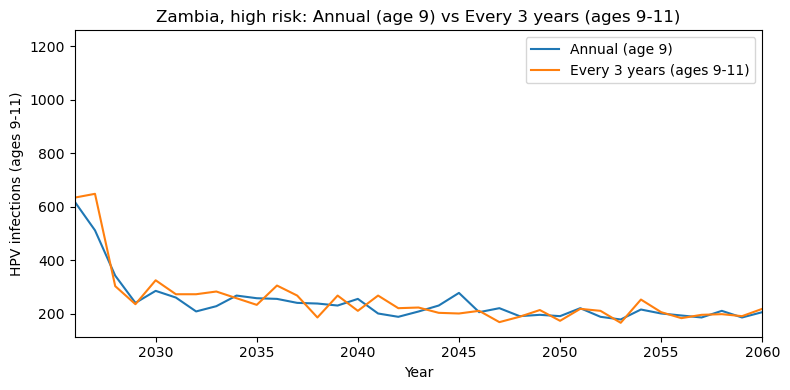

Mean annual absolute difference in infections : 7.933354829379459
zambia, HR, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 8550.068889427186
Alternative scenario sum: 8827.736308455467


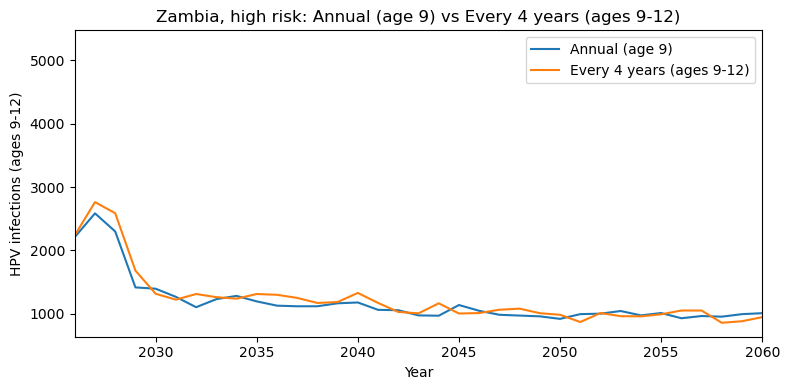

Mean annual absolute difference in infections : 46.37960305282052
zambia, HR, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 41632.471815299985
Alternative scenario sum: 43255.7579221487


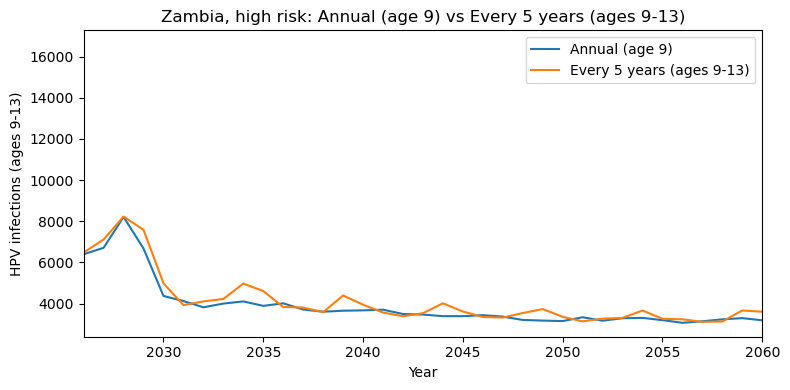

Mean annual absolute difference in infections : 218.50783606392963
zambia, HR, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 136810.0058057785
Alternative scenario sum: 144457.78006801603


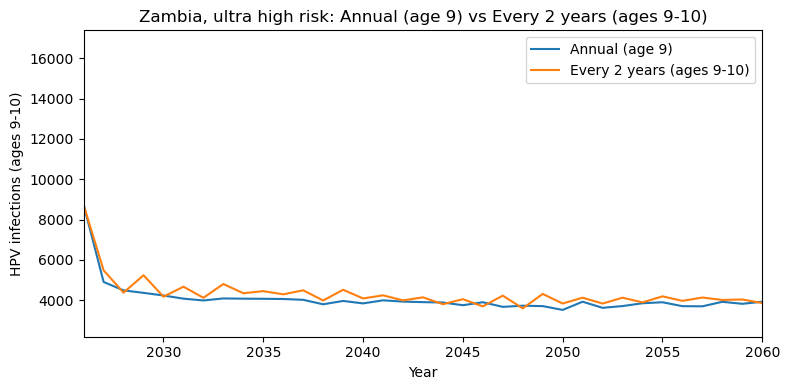

Mean annual absolute difference in infections : 258.5435231236051
zambia, UHR, vx_annual_9-10 vs vx_biennial_9-11:
Annual scenario sum: 142962.65932617185
Alternative scenario sum: 152011.68263549803


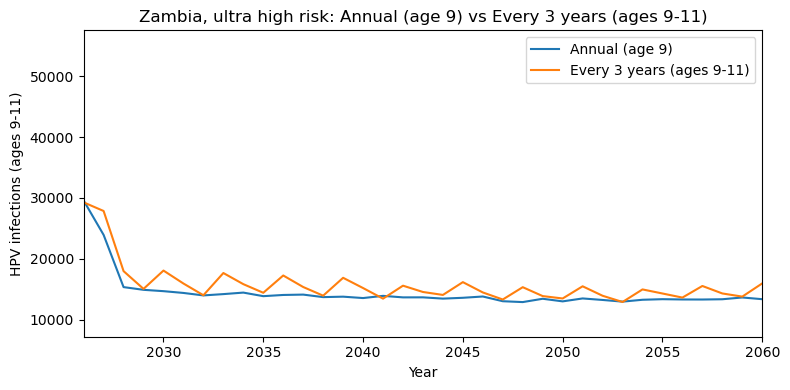

Mean annual absolute difference in infections : 1357.9627429199206
zambia, UHR, vx_annual_9-10 vs vx_triennial_9-12:
Annual scenario sum: 505958.275
Alternative scenario sum: 553486.9710021972


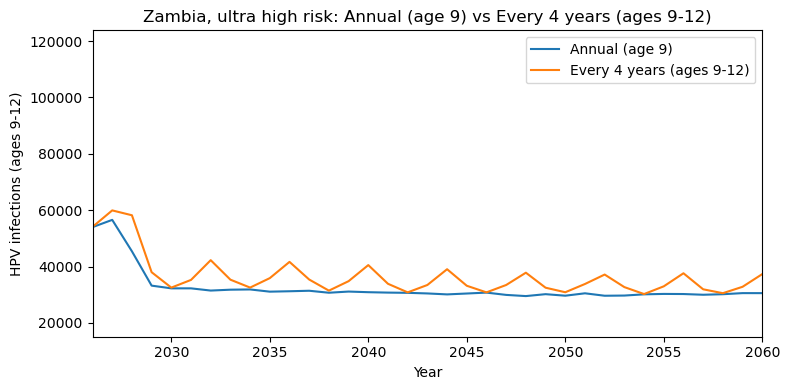

Mean annual absolute difference in infections : 4034.9278400530106
zambia, UHR, vx_annual_9-10 vs vx_quadrennial_9-13:
Annual scenario sum: 1139478.6468261718
Alternative scenario sum: 1280701.1212280272


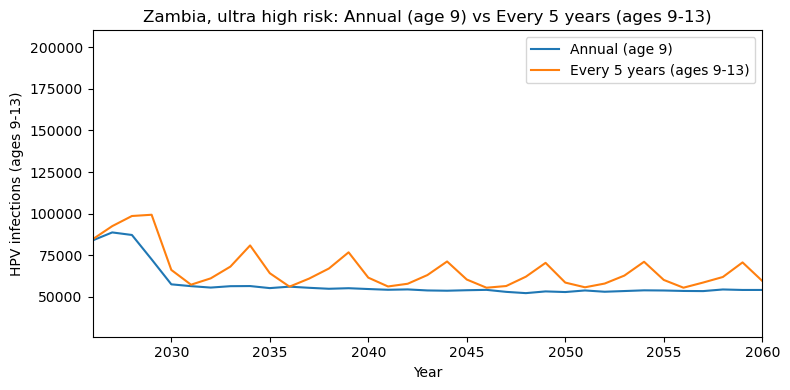

Mean annual absolute difference in infections : 8616.262467215396
zambia, UHR, vx_annual_9-10 vs vx_quinquennial_9-14:
Annual scenario sum: 2018286.7115722657
Alternative scenario sum: 2319855.8979248046


Bad pipe message: %s [b')FHG\xc6\xbc\xf1-`\xd2\xd4\xc8\xc5\xa8o\xd8_4\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00']
Bad pipe message: %s [b'\x06\x00\x07\x00']
Bad pipe message: %s [b'\xd0ju\x17\x873\xc5\xcc7_\x8aW\xc9\x12\xdb\x8b\xa9\xb6\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B']
Bad pipe message: %s [b'\t\x00\n\x00\x0b\x00\x0c']
Bad pipe message: %s [b'\x1e6t$N_\xb9\x8b,L\xda\x88\xbe\x94\xd0\x11\x98\x11\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00', b'\x06\x00\x07\x00']
Bad pipe message: %s [b'\t\x00\n\x00\x0b\x00\x0c']
Bad pipe message: %s [b'eW\xc6\x83', b'E\xb9\x05|\x8a\xf1\xac\xd9eU\xc9\xfd\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x

In [ ]:

# Define scenario pairs and age/year selection rules
scenario_pairs = [
    # (annual_scen, alt_scen, ages_to_compare)
    ('vx_annual_9-10', 'vx_biennial_9-11', [9, 10]),
    ('vx_annual_9-10', 'vx_triennial_9-12', [9, 10, 11]),
    ('vx_annual_9-10', 'vx_quadrennial_9-13', [9, 10, 11, 12]),
    ('vx_annual_9-10', 'vx_quinquennial_9-14', [9, 10, 11, 12, 13]),
]
compare_start_year = 2026

results = []

for country in ['cote_d_ivoire', 'zambia']:
    for risk_scenario in ['NAT', 'HR', 'UHR']:
        for calibration_source in ['nov06']:
            # Load annual scenario
            filename_annual = f"{country}_vx_annual_9-10_{risk_scenario}_{calibration_source}.obj"
            filepath_annual = results_dir / filename_annual
            if not filepath_annual.exists():
                continue
            result_annual = sc.loadobj(filepath_annual)
            hpv_by_age_annual = result_annual.results['infections_by_age'].values #*4 to convert to annual, and Multiply by 2 to be conservative, assume all incidence is in women

            for annual_scen, alt_scen, ages_to_compare in scenario_pairs:
                filename_alt = f"{country}_{alt_scen}_{risk_scenario}_{calibration_source}.obj"
                filepath_alt = results_dir / filename_alt
                if not filepath_alt.exists():
                    continue
                result_alt = sc.loadobj(filepath_alt)
                hpv_by_age_alt = result_alt.results['infections_by_age'].values #*4 to convert to annual, and Multiply by 2 to be conservative, assume all incidence is in women

                annual_vals = []
                alt_vals = []
                # For each scenario, sum incidence for the specified ages over all years >= compare_start_year
                age_indices = [np.where(age_bin_edges == age)[0][0] for age in ages_to_compare if age in age_bin_edges]
                year_indices = np.where(years >= compare_start_year)[0]
                # Plot incidence in this age group over time for both scenarios
                annual_series = hpv_by_age_annual[age_indices, :].sum(axis=0)
                alt_series = hpv_by_age_alt[age_indices, :].sum(axis=0)
                plt.figure(figsize=(8, 4))
                plt.plot(years, annual_series, label=f"{scenario_labels[annual_scen]}")
                plt.plot(years, alt_series, label=f"{scenario_labels[alt_scen]}")
                plt.xlim(compare_start_year, years[-1])
                plt.xlabel("Year")
                plt.ylabel(f"HPV infections (ages {ages_to_compare[0]}-{ages_to_compare[-1]})")
                plt.title(f"{country.capitalize().replace('_d_ivoire', " d'Ivoire")}, {risk_scenario.replace('NAT','national').replace('HR', 'high risk').replace('U', 'ultra ')}: {scenario_labels[annual_scen]} vs {scenario_labels[alt_scen]}")
                plt.legend()
                plt.tight_layout()
                plt.show()
                # Divide by the width of the age window (max age - min age + 1)
                age_window_width = ages_to_compare[-1] - ages_to_compare[0] + 1
                annual_sum = hpv_by_age_annual[np.ix_(age_indices, year_indices)].sum()
                alt_sum = hpv_by_age_alt[np.ix_(age_indices, year_indices)].sum()
                abs_diff = (alt_sum - annual_sum) / len(year_indices)
                pct_diff = (alt_sum - annual_sum) / annual_sum * 100 if annual_sum != 0 else 0
                print("Mean annual absolute difference in infections :", abs_diff)
                print(f"{country}, {risk_scenario}, {annual_scen} vs {alt_scen}:")
                print("Annual scenario sum:", annual_sum)
                print("Alternative scenario sum:", alt_sum)
                results.append({
                    'country': country,
                    'risk_scenario': risk_scenario,
                    'comparison': f"{annual_scen}_vs_{alt_scen}",
                    'ages': ages_to_compare,
                    'years': years[year_indices],
                    'annual_sum': annual_sum,
                    'alt_sum': alt_sum,
                    'abs_diff': abs_diff,
                    'pct_diff': pct_diff
                })


In [91]:
import pandas as pd

# Create a DataFrame from the results list
results_table = pd.DataFrame([
    {
        'comparison': r['comparison'],
        'country_risk': (r['country'], r['risk_scenario']),
        'pct_diff': r['pct_diff']
    }
    for r in results
])

# Pivot the table: rows=comparison, columns=(country, risk_scenario), values=abs_diff
pivot_table = results_table.pivot_table(
    index='comparison',
    columns='country_risk',
    values='pct_diff'
)

# Display the table
pivot_table
pivot_table.to_csv("comparison_pct_diff_pivot.csv")

In [ ]:
results_dir = project_dir / "hpv_scenarios" / "results" / "vaccination"
figure_dir = project_dir / "figures" 

# Example placeholders for loop values
countries = ['cote_d_ivoire', 'zambia']  # e.g., ['Kenya', 'India']
vx_scenarios = ['baseline',  'vx_annual_9-10', 'vx_biennial_9-11', 'vx_triennial_9-12', 
'vx_quadrennial_9-13', 'vx_quinquennial_9-14', 'vx_sextennial_9-15', 'vx_septennial_9-16', 
'vx_octennial_9-17', 'vx_nonennial_9-18', 'vx_decennial_9-19']  
risk_scenarios = ['NAT', 'HR', 'UHR']  # e.g., ['low', 'high']
calibration_sources = ['nov06']  # e.g., ['source1', 'source2']

for country in countries:
    for risk_scenario in risk_scenarios:
        for calibration_source in calibration_sources:
            # Plot HPV incidence
            plt.figure(figsize=(10, 5))
            for vx_scenario in vx_scenarios:
                filename = f"{country}_{vx_scenario}_{risk_scenario}_{calibration_source}.obj"
                filepath = results_dir / filename
                if filepath.exists():
                    result = sc.loadobj(filepath)
                    t = result.results['t']+1960
                    #hpv_inc = (result.results['hpv_incidence_by_genotype'].values.T[:,0:3]).sum(axis=1)
                    hpv_inc = (result.results['hpv_incidence'].values)
                    plt.plot(t, hpv_inc, label=f"{vx_scenario}")
            # Set a descriptive title for the HPV incidence plot
            country_name = country.capitalize().replace('_d_ivoire', " d'Ivoire")
            risk_label = risk_scenario.replace('NAT', 'national').replace('HR', 'high risk')
            # Remove 'jul2' from calibration_source and replace 'nov06' with '3'
            calib_label = calibration_source.replace('jul2', '').replace('nov06', '3')
            plt.title(f"HPV Incidence: {country_name}, {risk_label}, calibration {calib_label}")
            plt.xlabel("Year")
            plt.ylabel("HPV Incidence")
            plt.legend()
            plt.xlim(2025, t[-1])
            # Set ylim: 0 to 1.1 * max(y) for x > 2010
            y_max = 0.01
            for line in plt.gca().get_lines():
                xdata = line.get_xdata()
                ydata = line.get_ydata()
                mask = xdata > 2030
                y_min=0
                if np.any(mask):
                    y_max = max(y_max, np.max(ydata[mask]))
                    y_min = min(y_min, np.min(ydata[mask]))
            plt.ylim(y_min, y_max * 1.1)
            plt.xticks(np.arange(2025, t[-1]+1, 5))
            plt.tight_layout()
            # Save the HPV incidence figure
            fig_filename = f"hpv_incidence_{country}_{risk_scenario}_{calibration_source}.png"
            plt.savefig(figure_dir / fig_filename)
            plt.show()
            plt.close()


File not found: cote_d_ivoire_baseline_HR_nov06.obj


array([0.12 , 0.154, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018,
       0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016,
       0.016, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.012, 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.008,
       0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008,
       0.05 , 0.015, 0.005, 0.   ])

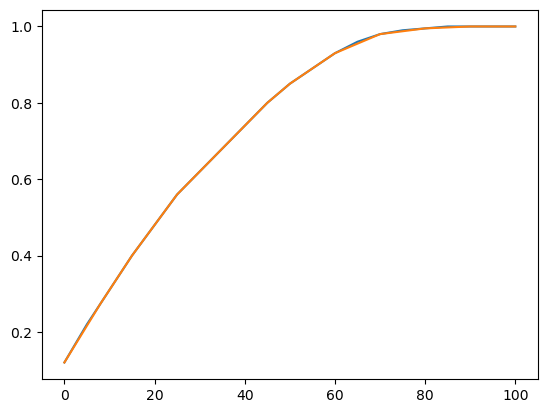

In [61]:
edges = np.array( [  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,  75,    80,    85, 100])
std_pop = np.array([.12, .10, .09, .09, .08, .08, .06, .06, .06, .06, .05, .04, .04, .03, .02, .01, 0.005, 0.005,   0])

std_pop_cumsum = std_pop.cumsum()
new_edges = np.array([0] + list(np.arange(8, 61)) + [70, 80, 90, 100])
new_stdpop_cumsum = np.interp(new_edges, edges, std_pop_cumsum)
new_stdpop = np.diff(new_stdpop_cumsum, prepend=0)
new_stdpop 
std_pop.sum()
plt.plot(edges,std_pop_cumsum)
plt.plot(new_edges,new_stdpop_cumsum)
new_stdpop


In [66]:
new_stdpop = new_stdpop/new_stdpop.sum()
new_stdpop.sum()

1.0

In [67]:
new_stdpop

array([0.12 , 0.154, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018,
       0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016,
       0.016, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.012, 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.008,
       0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008,
       0.05 , 0.015, 0.005, 0.   ])

In [73]:
np.array([new_edges, new_stdpop])

array([[0.00e+00, 8.00e+00, 9.00e+00, 1.00e+01, 1.10e+01, 1.20e+01,
        1.30e+01, 1.40e+01, 1.50e+01, 1.60e+01, 1.70e+01, 1.80e+01,
        1.90e+01, 2.00e+01, 2.10e+01, 2.20e+01, 2.30e+01, 2.40e+01,
        2.50e+01, 2.60e+01, 2.70e+01, 2.80e+01, 2.90e+01, 3.00e+01,
        3.10e+01, 3.20e+01, 3.30e+01, 3.40e+01, 3.50e+01, 3.60e+01,
        3.70e+01, 3.80e+01, 3.90e+01, 4.00e+01, 4.10e+01, 4.20e+01,
        4.30e+01, 4.40e+01, 4.50e+01, 4.60e+01, 4.70e+01, 4.80e+01,
        4.90e+01, 5.00e+01, 5.10e+01, 5.20e+01, 5.30e+01, 5.40e+01,
        5.50e+01, 5.60e+01, 5.70e+01, 5.80e+01, 5.90e+01, 6.00e+01,
        7.00e+01, 8.00e+01, 9.00e+01, 1.00e+02],
       [1.20e-01, 1.54e-01, 1.80e-02, 1.80e-02, 1.80e-02, 1.80e-02,
        1.80e-02, 1.80e-02, 1.80e-02, 1.60e-02, 1.60e-02, 1.60e-02,
        1.60e-02, 1.60e-02, 1.60e-02, 1.60e-02, 1.60e-02, 1.60e-02,
        1.60e-02, 1.20e-02, 1.20e-02, 1.20e-02, 1.20e-02, 1.20e-02,
        1.20e-02, 1.20e-02, 1.20e-02, 1.20e-02, 1.20e-02, 1.20e-02,

In [70]:
np.array([np.array([0] + list(range(8, 61)) + [100]), 
                                        np.array([0.12 , 0.154, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018, 0.018,
                                        0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016, 0.016,
                                        0.016, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
                                        0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
                                        0.012, 0.012, 0.012, 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.008,
                                        0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008,
                                        0.05 , 0.015, 0.005, 0.   ])])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [88]:
c=np.array([
                # Share of females (row 1) and males (row 2) of each age having casual relationships
                [0, 5,   10,   15,   20,   25,   30,   35,   40,   45,   50,   55,   60,   65,   70,   75],  # Age bracket
                [0, 0, 0.10, 0.10, 0.20, 0.30, 0.50, 0.50, 0.50, 0.40, 0.40, 0.40, 0.20, 0.10, 0.01, 0.01],  # Share f
                [0, 0, 0.10, 0.20, 0.50, 0.60, 0.80, 0.90, 0.90, 0.80, 0.80, 0.70, 0.50, 0.30, 0.10, 0.10]],  # Share m
            )

In [90]:
c[1, :]

array([0.  , 0.  , 0.1 , 0.1 , 0.2 , 0.3 , 0.5 , 0.5 , 0.5 , 0.4 , 0.4 ,
       0.4 , 0.2 , 0.1 , 0.01, 0.01])